In [ ]:
!pip install -q ultralytics

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO


DATA_PATH = "/kaggle/input/datasets/ishaantoraskar/urpc-procesed"

MODES = ["original", "noisy", "enhanced"]

def get_mode_path(mode):
    return f"{DATA_PATH}/{mode}/{mode}"

def create_yaml(mode):
    base = get_mode_path(mode)
    path = f"/kaggle/working/{mode}.yaml"

    train_path = f"{base}/train/images"
    val_path   = f"{base}/valid/images"
    test_path  = f"{base}/test/images"

    if not os.path.exists(train_path):
        raise Exception(f"Train path missing: {train_path}")
    if not os.path.exists(val_path):
        raise Exception(f"Val path missing: {val_path}")

    with open(path, "w") as f:
        f.write(f"""
train: {train_path}
val: {val_path}
test: {test_path}

nc: 4
names: ['holothurian','echinus','scallop','starfish']
""")
    return path

print("STEP 1: TRAINING")

model = YOLO("yolov8m.pt")

results = model.train(
    data=create_yaml("mixed"),
    epochs=80,
    imgsz=640,
    batch=8,
    device=0,
    mosaic=0.3,
    mixup=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5,
    translate=0.1,
    shear=1.0,

    patience=20,
    save=True,
    verbose=True
)

best_model_path = os.path.join(results.save_dir, "weights/best.pt")
print("\nBest model saved at:", best_model_path)

model = YOLO(best_model_path)

print("\nSTEP 2: EVALUATION")

def evaluate(mode, split="val"):
    print(f"\nEvaluating {mode} ({split})")
    m = model.val(
        data=create_yaml(mode),
        split=split,
        verbose=False,
        plots=False
    )
    return [mode, split, m.box.mp, m.box.mr, m.box.map50, m.box.map]

results_list = []

for mode in MODES:
    results_list.append(evaluate(mode, "val"))
    results_list.append(evaluate(mode, "test"))

df = pd.DataFrame(
    results_list,
    columns=["mode", "split", "precision", "recall", "mAP50", "mAP50-95"]
)

print("\nFINAL RESULTS")
print(df)



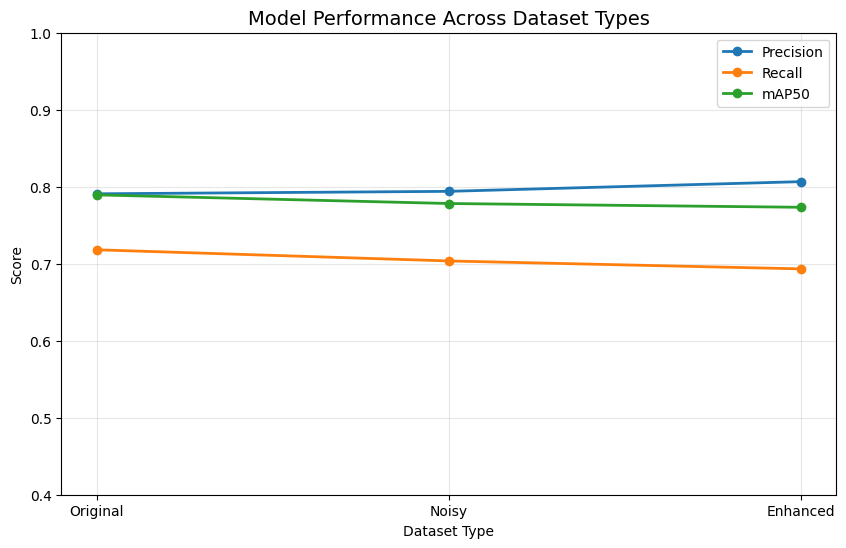

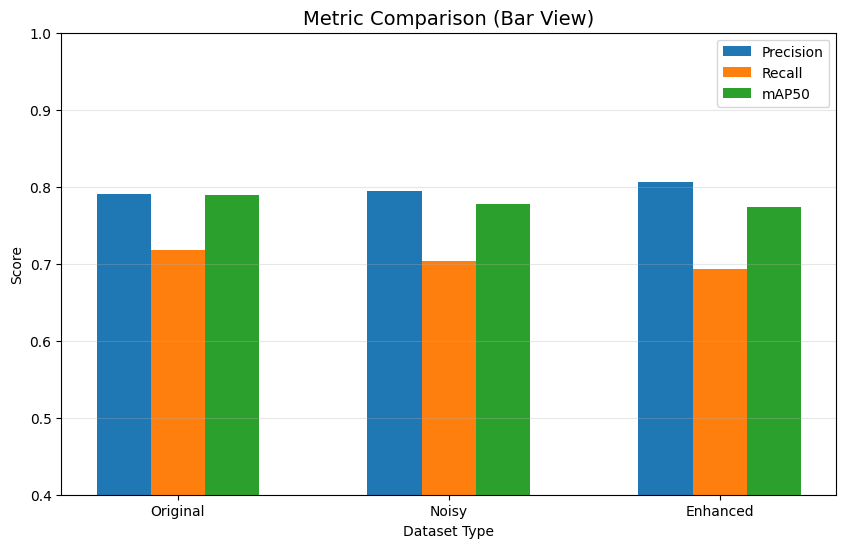

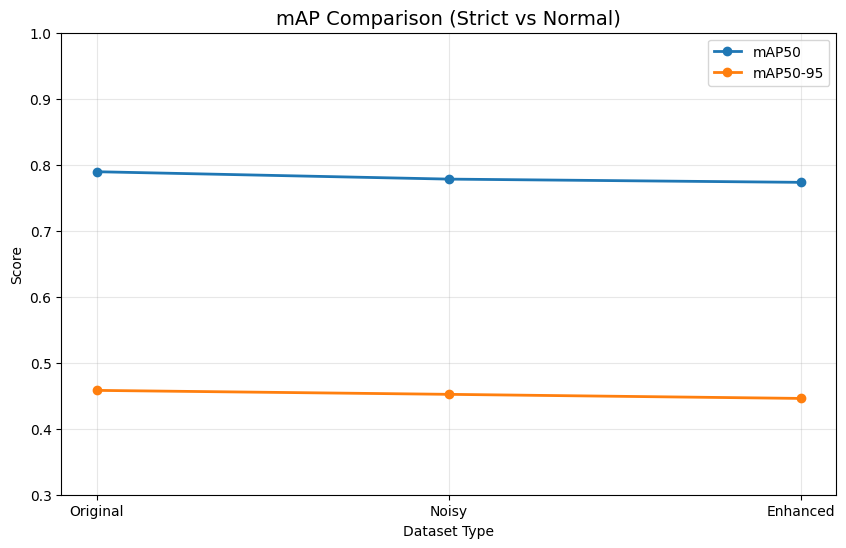

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df_test = df[df["split"] == "test"]

# Extract values
modes = df_test["mode"].str.capitalize().tolist()
precision = df_test["precision"].tolist()
recall = df_test["recall"].tolist()
map50 = df_test["mAP50"].tolist()
map5095 = df_test["mAP50-95"].tolist()

x = np.arange(len(modes))

# =========================
# PLOT 1: Line Comparison
# =========================
plt.figure(figsize=(10, 6))

plt.plot(modes, precision, marker='o', linewidth=2, label="Precision")
plt.plot(modes, recall, marker='o', linewidth=2, label="Recall")
plt.plot(modes, map50, marker='o', linewidth=2, label="mAP50")

plt.title("Model Performance Across Dataset Types", fontsize=14)
plt.xlabel("Dataset Type")
plt.ylabel("Score")
plt.ylim(0.4, 1.0)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, map50, width, label="mAP50")

plt.xticks(x, modes)
plt.ylim(0.4, 1.0)

plt.title("Metric Comparison (Bar View)", fontsize=14)
plt.xlabel("Dataset Type")
plt.ylabel("Score")
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

plt.figure(figsize=(10, 6))

plt.plot(modes, map50, marker='o', linewidth=2, label="mAP50")
plt.plot(modes, map5095, marker='o', linewidth=2, label="mAP50-95")

plt.title("mAP Comparison (Strict vs Normal)", fontsize=14)
plt.xlabel("Dataset Type")
plt.ylabel("Score")
plt.ylim(0.3, 1.0)
plt.grid(alpha=0.3)
plt.legend()

plt.show()